In [ ]:
Stress Level Prediction using KNN on synthetic survey-style data

In [1]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 500

df = pd.DataFrame({
    "Gender": np.random.choice([1, 2], rows),  # 1-Male, 2-Female
    "Financial_Issues": np.random.choice([0, 1], rows),
    "Family_Issues": np.random.choice([0, 1], rows),
    "Study_Hours": np.random.randint(1, 8, rows),
    "Teaching_Method": np.random.choice([0, 1], rows),
    "Health_Issues": np.random.choice([0, 1], rows),
    "Partiality": np.random.choice([0, 1], rows),
    "Exam_Schedule": np.random.choice([1, 2, 3, 4, 5], rows),
    "Friend_Issues": np.random.choice([0, 1], rows),
    "Pressure": np.random.choice([0, 1], rows),
    "Regular": np.random.choice([0, 1], rows),
    "Interaction": np.random.choice([1, 2, 3, 4], rows),
})

# Create synthetic target variable
df["Stress_Level"] = np.where(
    (df["Financial_Issues"] == 1) |
    (df["Family_Issues"] == 1) |
    (df["Pressure"] == 1) |
    (df["Health_Issues"] == 1),
    "Stressed",
    "Stress_Free"
)

df.to_csv("dataset.csv", index=False)
df.head()


,Gender,Financial_Issues,Family_Issues,Study_Hours,Teaching_Method,Health_Issues,Partiality,Exam_Schedule,Friend_Issues,Pressure,Regular,Interaction,Stress_Level
0,1,0,1,3,0,1,1,4,0,1,1,2,Stressed
1,2,0,0,6,1,0,1,5,0,1,1,1,Stressed
2,1,0,0,6,0,1,1,4,0,1,0,1,Stressed
3,1,1,0,3,1,1,1,3,0,1,0,3,Stressed
4,1,0,0,7,1,1,0,2,1,0,0,4,Stressed


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix


In [5]:
df = pd.read_csv("dataset.csv")
df.head()


,Gender,Financial_Issues,Family_Issues,Study_Hours,Teaching_Method,Health_Issues,Partiality,Exam_Schedule,Friend_Issues,Pressure,Regular,Interaction,Stress_Level
0,1,0,1,3,0,1,1,4,0,1,1,2,Stressed
1,2,0,0,6,1,0,1,5,0,1,1,1,Stressed
2,1,0,0,6,0,1,1,4,0,1,0,1,Stressed
3,1,1,0,3,1,1,1,3,0,1,0,3,Stressed
4,1,0,0,7,1,1,0,2,1,0,0,4,Stressed


In [7]:
df_encoded = pd.get_dummies(df, drop_first=True)

X = df_encoded.drop("Stress_Level_Stressed", axis=1)
y = df_encoded["Stress_Level_Stressed"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [9]:
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train, y_train)


KNeighborsClassifier()

              precision    recall  f1-score   support

       False       1.00      0.67      0.80         3
        True       0.99      1.00      0.99        97

    accuracy                           0.99       100
   macro avg       0.99      0.83      0.90       100
weighted avg       0.99      0.99      0.99       100



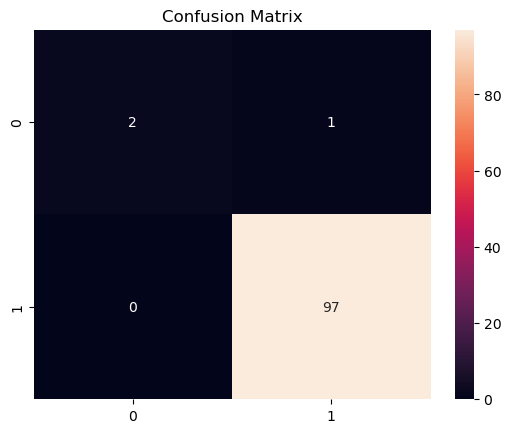

In [11]:
y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))

sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()
